# Averaging an estimator over many trials, step by step

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/homework/hw04/walkthrough.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

This notebook builds the program for the *shape* of the Homework 4 programming problem,
one step at a time. **The question here is not the homework question.** We toss a coin
that lands heads with probability $p = 0.3$ and estimate $p^2 = 0.09$ by the square of the
sample proportion,

$$\widehat\theta_n = \bigl(\overline{X}_n\bigr)^2, \qquad X_i = 1 \text{ (heads) or } 0 \text{ (tails)} .$$

This estimator is biased: $\mathbb{E}[\widehat\theta_n] = p^2 + p(1-p)/n$, a little more than $p^2$.
We check that by simulation, which is exactly what the homework asks you to do for a
different estimator.

How to use it: run each cell with **Shift+Enter**, in order, from the top. Then change a
number and run the cell again; you cannot damage anything here.

The program has five steps:

1. make the list of sample sizes;
2. make room to store one number for each sample size;
3. for each sample size, repeat many times: draw a sample, compute the estimator on it,
   keep the value; then store the average of those values;
4. plot the stored averages against the sample size;
5. add the curve the theory predicts, to compare.

## Step 0: the setup

`numpy` for numbers, `matplotlib` for plots, and a random number generator with a fixed
seed, so that the numbers below are the same every time. Run this cell first.

In [1]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(1)       # change the 1, or drop it, for different random numbers
p = 0.3                              # probability of heads

## Step 1: one sample, one estimate

Draw $n = 10$ coin tosses and compute the estimator once. `rng.random(n) < p` is `True`
with probability $p$; multiplying by `1.0` turns `True`/`False` into `1.0`/`0.0`.

In [2]:
n = 10
x = (rng.random(n) < p) * 1.0        # 10 tosses: 1.0 = heads, 0.0 = tails
est = np.mean(x) ** 2                # the estimator, computed from this one sample

print("tosses:  ", x)
print(f"estimate: {est:.4f}   (true value p^2 = {p**2:.4f})")

tosses:   [0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
estimate: 0.0400   (true value p^2 = 0.0900)


Run the cell again: you get a different sample and a different estimate. **One estimate
tells you nothing about bias.** Bias is about the *average* over many samples.

## Step 2: many samples at one sample size

Repeat Step 1 a hundred times, keep every estimate, and average them. That average
estimates $\mathbb{E}[\widehat\theta_n]$.

In [3]:
n = 10
trials = 100
est = np.zeros(trials)               # room for one estimate per trial

for t in range(trials):              # t = 0, 1, ..., 99
    x = (rng.random(n) < p) * 1.0    # a fresh sample every time
    est[t] = np.mean(x) ** 2

print(f"average of 100 estimates: {np.mean(est):.4f}")
print(f"exact E[estimate]:        {p**2 + p * (1 - p) / n:.4f}")
print(f"true value p^2:           {p**2:.4f}")

average of 100 estimates: 0.1086
exact E[estimate]:        0.1110
true value p^2:           0.0900


The average sits near the exact value $p^2 + p(1-p)/n = 0.111$, not near $p^2 = 0.09$:
the estimator overestimates. It is not exactly $0.111$, because 100 trials is still a
finite number of trials.

## Step 3: a loop over sample sizes, with the loop over trials inside

Now do Step 2 for every $n = 3, 4, \dots, 100$ and store one average per $n$. The loop over
trials moves *inside* a loop over sample sizes. Note that `est` is made again for every $n$,
so each sample size starts fresh.

In [4]:
nvals = np.arange(3, 101)            # 1. the sample sizes 3, 4, ..., 100 (arange leaves out 101)
avg_est = np.zeros(nvals.size)       # 2. room for one average per sample size
trials = 100

for k in range(nvals.size):          # 3. outer loop: one sample size at a time
    n = nvals[k]
    est = np.zeros(trials)           #    room for this sample size's estimates
    for t in range(trials):          #    inner loop: one fresh sample at a time
        x = (rng.random(n) < p) * 1.0
        est[t] = np.mean(x) ** 2
    avg_est[k] = np.mean(est)        #    store the average for this sample size

print("first three averages:", np.round(avg_est[:3], 4), "  for n =", nvals[:3])
print("last three averages: ", np.round(avg_est[-3:], 4), "  for n =", nvals[-3:])

first three averages: [0.1411 0.1556 0.1416]   for n = [3 4 5]
last three averages:  [0.0882 0.0904 0.092 ]   for n = [ 98  99 100]


## Steps 4 and 5: plot, and compare with the theory

Plot the averages against $n$, then add the exact curve $p^2 + p(1-p)/n$ and the true
value $p^2$.

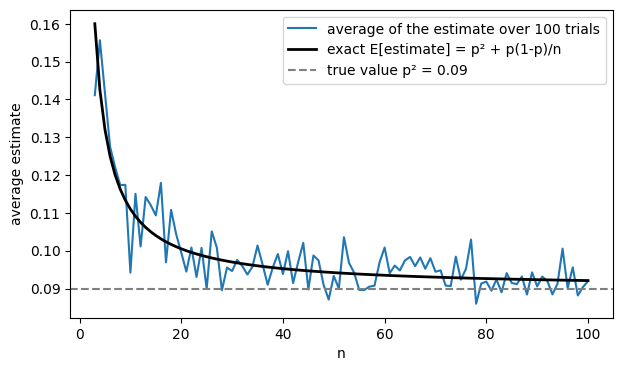

In [5]:
exact = p**2 + p * (1 - p) / nvals   # 5. what the theory predicts, for every n

plt.figure(figsize=(7, 4))
plt.plot(nvals, avg_est, label="average of the estimate over 100 trials")       # 4.
plt.plot(nvals, exact, color="black", lw=2, label="exact E[estimate] = p² + p(1-p)/n")
plt.axhline(p**2, color="gray", linestyle="--", label="true value p² = 0.09")
plt.xlabel("n")
plt.ylabel("average estimate")
plt.legend()
plt.show()

The averages scatter around the black curve, more for small $n$ where a single estimate
varies a lot, and the curve itself comes down to $p^2$ as $n$ grows: the bias $p(1-p)/n$
vanishes like $1/n$. Describing a plot like this one is what the homework asks for.

## Two ways to compute a variance

The homework's estimator is a variance, and the built-in functions do not all compute
the same one. For one sample of size $n$:

* dividing by $n$: $\;\frac{1}{n}\sum_i (x_i-\overline{x})^2 = \overline{x^2} - \overline{x}^{\,2}$, which is `np.var(x)`;
* dividing by $n-1$: $\;\frac{1}{n-1}\sum_i (x_i-\overline{x})^2$, which is `np.var(x, ddof=1)`.

Read the problem carefully to see which one it asks for. (In MATLAB, R, and Julia, `var`
divides by $n-1$ unless told otherwise.)

In [6]:
x = rng.random(5)                    # any small sample will do
n = x.size
print(f"divide by n,     by hand:           {np.sum((x - np.mean(x))**2) / n:.6f}")
print(f"divide by n,     np.var(x):         {np.var(x):.6f}")
print(f"divide by n - 1, by hand:           {np.sum((x - np.mean(x))**2) / (n - 1):.6f}")
print(f"divide by n - 1, np.var(x, ddof=1): {np.var(x, ddof=1):.6f}")

divide by n,     by hand:           0.012664
divide by n,     np.var(x):         0.012664
divide by n - 1, by hand:           0.015830
divide by n - 1, np.var(x, ddof=1): 0.015830


## A shortcut without the inner loop (optional)

Instead of drawing the 100 samples one at a time, draw them all at once as the rows of a
$100 \times n$ matrix and work row by row with `axis=1`. This does the same as the inner
loop of Step 3, only faster. Use whichever you understand; the loop is easier to get right.

In [7]:
n = 10
X = (rng.random((100, n)) < p) * 1.0     # 100 samples of size n, one per row
est = np.mean(X, axis=1) ** 2            # one estimate per row: 100 values
print(est.shape, "  average:", round(np.mean(est), 4))

(100,)   average: 0.1134


## What to change for the homework

* **The distribution.** Replace the coin tosses by draws from the distribution in the problem.
  `rng.standard_normal(n)` gives $n$ draws from $\mathcal{N}(0,1)$.
* **The estimator.** Replace `np.mean(x) ** 2` by the estimator the problem asks about.
* **The theory curve.** Replace `exact` by the expected value from the theoretical problem.
* **Hand in a script.** Copy the cells of Steps 0, 3, 4 and 5 into one file and run it; that file
  is what you upload. Scripts doing the same in MATLAB, R, and Julia are in this folder.

## When something goes wrong

* `NameError: name 'np' is not defined`: run the setup cell (Step 0) first.
* `NameError: name 'nvals' is not defined` in Step 4: run Step 3 first. Cells use what earlier
  cells made, so run them in order (**Runtime > Run all**).
* The plot shows a flat line at 0: the room for the averages was made but never filled.
  Check that `avg_est[k] = ...` is inside the outer loop.
* All averages look the same: check that the sample is drawn *inside* the inner loop, so that
  every trial gets a fresh sample.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University.